In [ ]:
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import os


In [3]:
fold1 = pd.read_csv('/media/yusuf/HDD 4TB/Rotated/Processed/sinfo__fold1__.csv')

fold1_test = fold1[fold1['set'] == 1]
len(fold1_test)

50

In [37]:
distances = []
for v in fold1_test['processed__csv_path']:
    try:
        dataframe = pd.read_csv('/media/yusuf/HDD 4TB/Rotated/Processed/' + v)
        dx = (dataframe[dataframe['label'].isin(['enR', 'enL'])]['x'][1] - dataframe[dataframe['label'].isin(['enR', 'enL'])]['x'][3]) ** 2
        dy = (dataframe[dataframe['label'].isin(['enR', 'enL'])]['y'][1] - dataframe[dataframe['label'].isin(['enR', 'enL'])]['y'][3]) ** 2
        dz = (dataframe[dataframe['label'].isin(['enR', 'enL'])]['z'][1] - dataframe[dataframe['label'].isin(['enR', 'enL'])]['z'][3]) ** 2

        distances.append(math.sqrt(dx + dy + dz))
    except Exception as e:
        pass

distances = np.array(distances)

distances.mean(), distances.std()


(16.1407034463633, 3.5834842934027757)

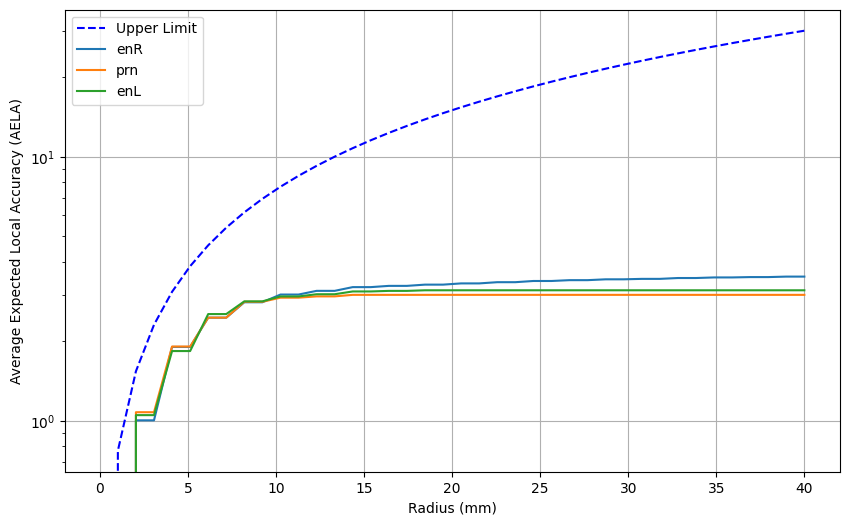

In [ ]:
csv_folder = '/home/yusuf/Source/fetusnet/runs/2025-06-11/traning_2_in_prn_enL_enR_pg_n_sl_li_ls_chR_chL_sn_exL_exR_cphR_cphL_acL_acR_aR_aL/fold_1/curves/'

csv_files = [f for f in os.listdir(csv_folder) if f.endswith('.csv')]
csv_data = {}
for file in csv_files:
    file_path = os.path.join(csv_folder, file)
    # Split name and extension
    # Load the CSV file into a DataFrame
    file_name, _ = os.path.splitext(file)
    # Load the CSV file into a DataFrame
    # Extract the base name between the last slash and '_curve_mean.csv'
    base_name = file.split('_curve_mean.csv')[0]
    # print(base_name)
    csv_data[base_name] = pd.read_csv(file_path, header=None)

radii = torch.linspace(0, 40, 40)
upper_limit = [3 / 4 * r for r in radii]
plt.figure(figsize=(10, 6))
plt.plot(radii, upper_limit, linestyle='--', color='blue', label='Upper Limit')
for key, value in csv_data.items():
    if key in ['enL', 'enR', 'prn']:
        plt.plot(radii, value[0], label=key)

plt.legend(loc='best')
plt.xlabel('Radius (mm)')
plt.ylabel('Average Expected Local Accuracy (AELA)')
plt.yscale('log')

plt.grid()
save_path = f'tmps/{key}_aela_classifier.png'
plt.savefig(save_path)
plt.show()  # Show the plot

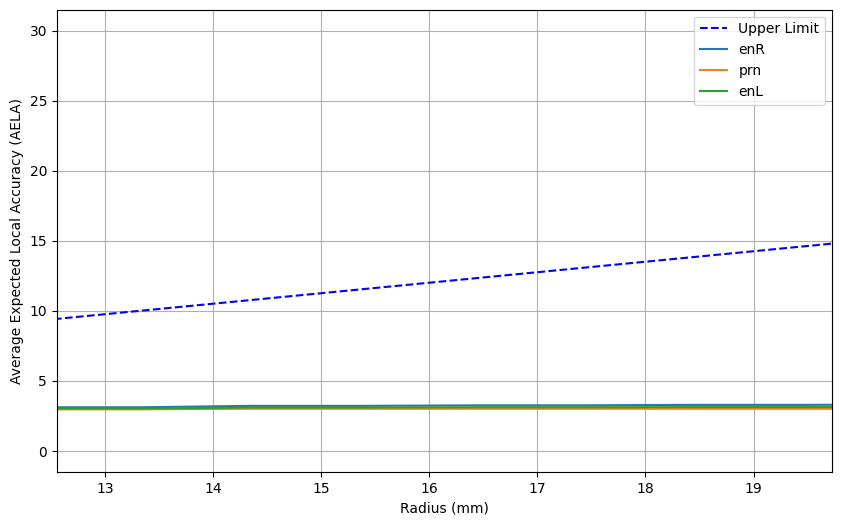

In [42]:
csv_folder = '/home/yusuf/Source/fetusnet/runs/2025-06-11/traning_2_in_prn_enL_enR_pg_n_sl_li_ls_chR_chL_sn_exL_exR_cphR_cphL_acL_acR_aR_aL/fold_1/curves/'

csv_files = [f for f in os.listdir(csv_folder) if f.endswith('.csv')]
csv_data = {}
for file in csv_files:
    file_path = os.path.join(csv_folder, file)
    # Split name and extension
    # Load the CSV file into a DataFrame
    file_name, _ = os.path.splitext(file)
    # Load the CSV file into a DataFrame
    # Extract the base name between the last slash and '_curve_mean.csv'
    base_name = file.split('_curve_mean.csv')[0]
    # print(base_name)
    csv_data[base_name] = pd.read_csv(file_path, header=None)

radii = torch.linspace(0, 40, 40)
upper_limit = [3 / 4 * r for r in radii]
plt.figure(figsize=(10, 6))
plt.plot(radii, upper_limit, linestyle='--', color='blue', label='Upper Limit')
for key, value in csv_data.items():
    if key in ['enL', 'enR', 'prn']:
        plt.plot(radii, value[0], label=key)

plt.legend(loc='best')

plt.xlim(16.1407034463633 - 3.5834842934027757, 16.1407034463633 + 3.5834842934027757)
plt.xlabel('Radius (mm)')
plt.ylabel('Average Expected Local Accuracy (AELA)')
# plt.yscale('log')

plt.grid()
save_path = f'tmps/{key}_aela_classifier.png'
plt.savefig(save_path)
plt.show()  # Show the plot

## Test Swap 

If I surprise the model by swapping two landmarks, I get a result close to the natural average distance between two: 

>> Test d-mean Score for enL:  15.01 +/- 3.14

 >> Test d-mean Score for enR:  15.11  +/- 2.69

## Test Flip